# Verifica risultati simulazione - Bologna morning

Notebook per ispezionare gli snapshot GeoJSON prodotti in `../results/bologna_morning`.

Controlla struttura dei file, feature vuote, metriche aggregate nel tempo, edge piu congestionati e una vista rapida della rete colorata per congestione.

In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULT_DIR = Path('/home/fede/code/nomad/results/bologna_morning')
FILES = sorted(RESULT_DIR.glob('network_state_*.geojson'))

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 50)
plt.rcParams['figure.figsize'] = (12, 6)

print(f'Cartella risultati: {RESULT_DIR}')
print(f'File trovati: {len(FILES)}')
for path in FILES:
    print(f'- {path.name} ({path.stat().st_size:,} bytes)')

Cartella risultati: /home/fede/code/nomad/results/bologna_morning
File trovati: 8
- network_state_025200.geojson (42 bytes)
- network_state_026100.geojson (44,157 bytes)
- network_state_027000.geojson (45,165 bytes)
- network_state_027900.geojson (55,380 bytes)
- network_state_028800.geojson (58,798 bytes)
- network_state_029700.geojson (52,196 bytes)
- network_state_030600.geojson (48,517 bytes)
- network_state_031500.geojson (42,683 bytes)


## Caricamento e controlli base

In [2]:
def seconds_from_name(path: Path) -> int:
    match = re.search(r'network_state_(\d+)\.geojson$', path.name)
    if not match:
        raise ValueError(f'Nome file inatteso: {path.name}')
    return int(match.group(1))


def hhmmss(seconds: int) -> str:
    h = seconds // 3600
    m = (seconds % 3600) // 60
    s = seconds % 60
    return f'{h:02d}:{m:02d}:{s:02d}'


def load_geojson(path: Path) -> dict:
    with path.open() as f:
        data = json.load(f)
    if data.get('type') != 'FeatureCollection':
        raise ValueError(f'{path.name}: type={data.get("type")!r}, atteso FeatureCollection')
    if not isinstance(data.get('features'), list):
        raise ValueError(f'{path.name}: campo features mancante o non lista')
    return data


snapshots = []
errors = []
for path in FILES:
    try:
        data = load_geojson(path)
        seconds = seconds_from_name(path)
        snapshots.append({
            'path': path,
            'seconds': seconds,
            'time': hhmmss(seconds),
            'features': data['features'],
            'feature_count': len(data['features']),
            'size_bytes': path.stat().st_size,
        })
    except Exception as exc:
        errors.append({'file': path.name, 'error': str(exc)})

summary = pd.DataFrame([
    {
        'file': s['path'].name,
        'time': s['time'],
        'seconds': s['seconds'],
        'feature_count': s['feature_count'],
        'size_kb': s['size_bytes'] / 1024,
    }
    for s in snapshots
])

print('Errori di caricamento:', len(errors))
if errors:
    display(pd.DataFrame(errors))
display(summary)

Errori di caricamento: 0


,file,time,seconds,feature_count,size_kb
0,network_state_025200.geojson,07:00:00,25200,0,0.041016
1,network_state_026100.geojson,07:15:00,26100,181,43.122070
2,network_state_027000.geojson,07:30:00,27000,185,44.106445
3,network_state_027900.geojson,07:45:00,27900,227,54.082031
4,network_state_028800.geojson,08:00:00,28800,241,57.419922
5,network_state_029700.geojson,08:15:00,29700,214,50.972656
6,network_state_030600.geojson,08:30:00,30600,199,47.379883
7,network_state_031500.geojson,08:45:00,31500,175,41.682617


In [3]:
empty = summary.loc[summary['feature_count'] == 0, ['file', 'time', 'feature_count']]
print(f'Snapshot vuoti: {len(empty)}')
display(empty)

non_empty_features = [feature for s in snapshots for feature in s['features']]
if non_empty_features:
    geometry_types = pd.Series([feature.get('geometry', {}).get('type') for feature in non_empty_features]).value_counts()
    property_keys = sorted({key for feature in non_empty_features for key in feature.get('properties', {}).keys()})
    print('Tipi geometria:')
    display(geometry_types.to_frame('count'))
    print('Chiavi properties:', property_keys)
    print('Esempio feature:')
    display(non_empty_features[0])
else:
    print('Nessuna feature trovata nei risultati.')

Snapshot vuoti: 1


,file,time,feature_count
0,network_state_025200.geojson,07:00:00,0


Tipi geometria:


,count
LineString,1422


Chiavi properties: ['congestion', 'count', 'edge_id', 'free_flow_time_s', 'road_class', 'travel_time_s']
Esempio feature:


{'type': 'Feature',
 'geometry': {'type': 'LineString',
  'coordinates': [[11.33709, 44.47411], [11.337051, 44.474106]]},
 'properties': {'edge_id': 138,
  'road_class': 10,
  'congestion': 0.15,
  'travel_time_s': 0.43212,
  'count': 1,
  'free_flow_time_s': 0.375757}}

## Metriche aggregate

In [5]:
rows = []
for s in snapshots:
    for feature in s['features']:
        props = feature.get('properties', {}) or {}
        rows.append({
            'file': s['path'].name,
            'time': s['time'],
            'seconds': s['seconds'],
            'edge_id': props.get('edge_id'),
            'road_class': props.get('road_class'),
            'congestion': props.get('congestion'),
            'count': props.get('count'),
            'travel_time_s': props.get('travel_time_s'),
            'free_flow_time_s': props.get('free_flow_time_s'),
        })

df = pd.DataFrame(rows)
numeric_cols = ['edge_id', 'road_class', 'congestion', 'count', 'travel_time_s', 'free_flow_time_s']
for col in numeric_cols:
    if col in df:
        df[col] = pd.to_numeric(df[col], errors='coerce')

if df.empty:
    print('DataFrame vuoto: non ci sono feature da aggregare.')
else:
    df['delay_s'] = df['travel_time_s'] - df['free_flow_time_s']
    df['speed_ratio'] = df['travel_time_s'] / df['free_flow_time_s']
    display(df.head())
    display(df.describe(include='all'))

,file,time,seconds,edge_id,road_class,congestion,count,travel_time_s,free_flow_time_s,delay_s,speed_ratio
0,network_state_026100.geojson,07:15:00,26100,138,10,0.15,1,0.432120,0.375757,0.056363,1.149999
1,network_state_026100.geojson,07:15:00,26100,2178,12,0.00,1,3.034662,3.034662,0.000000,1.000000
2,network_state_026100.geojson,07:15:00,26100,3042,6,0.00,1,4.034001,4.034001,0.000000,1.000000
3,network_state_026100.geojson,07:15:00,26100,3259,4,0.00,1,0.423967,0.423967,0.000000,1.000000
4,network_state_026100.geojson,07:15:00,26100,3284,4,0.00,1,0.979861,0.979861,0.000000,1.000000


,file,time,seconds,edge_id,road_class,congestion,count,travel_time_s,free_flow_time_s,delay_s,speed_ratio
count,1422,1422,1422.000000,1422.000000,1422.000000,1422.000000,1422.000000,1422.000000,1422.000000,1422.000000,1422.000000
unique,7,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,network_state_028800.geojson,08:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,241,241,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,28798.101266,125490.994374,6.147679,0.036146,1.003516,3.584797,3.561931,0.022866,1.036146
std,NaN,NaN,1718.509754,106158.948451,4.475517,0.061728,0.059214,8.173392,8.176855,0.074897,0.061728
min,NaN,NaN,26100.000000,92.000000,0.000000,0.000000,1.000000,0.073773,0.064150,0.000000,1.000000
25%,NaN,NaN,27000.000000,34342.000000,4.000000,0.000000,1.000000,0.566174,0.528976,0.000000,1.000000
50%,NaN,NaN,28800.000000,92773.000000,4.000000,0.000000,1.000000,1.141230,1.115289,0.000000,1.000000
75%,NaN,NaN,30600.000000,196391.250000,8.000000,0.071279,1.000000,2.948409,2.948409,0.018928,1.071279


,seconds,time,edges,active_edges,total_count,mean_count,mean_congestion,p95_congestion,max_congestion,mean_travel_time_s,mean_delay_s,max_delay_s
0,26100,07:15:00,181,181,181,1.000000,0.031553,0.15,0.15,3.780687,0.026075,0.765936
1,27000,07:30:00,185,185,185,1.000000,0.029489,0.15,0.15,4.309318,0.018702,0.633002
2,27900,07:45:00,227,227,229,1.008811,0.036450,0.15,0.15,3.487268,0.025553,0.672898
3,28800,08:00:00,241,241,241,1.000000,0.035437,0.15,0.15,3.995118,0.021837,0.757402
4,29700,08:15:00,214,214,215,1.004673,0.042967,0.15,0.15,3.659410,0.020216,0.500081
5,30600,08:30:00,199,199,200,1.005025,0.042014,0.15,0.15,2.420480,0.024211,0.643795
6,31500,08:45:00,175,175,176,1.005714,0.033499,0.15,0.15,3.410457,0.023594,0.707590


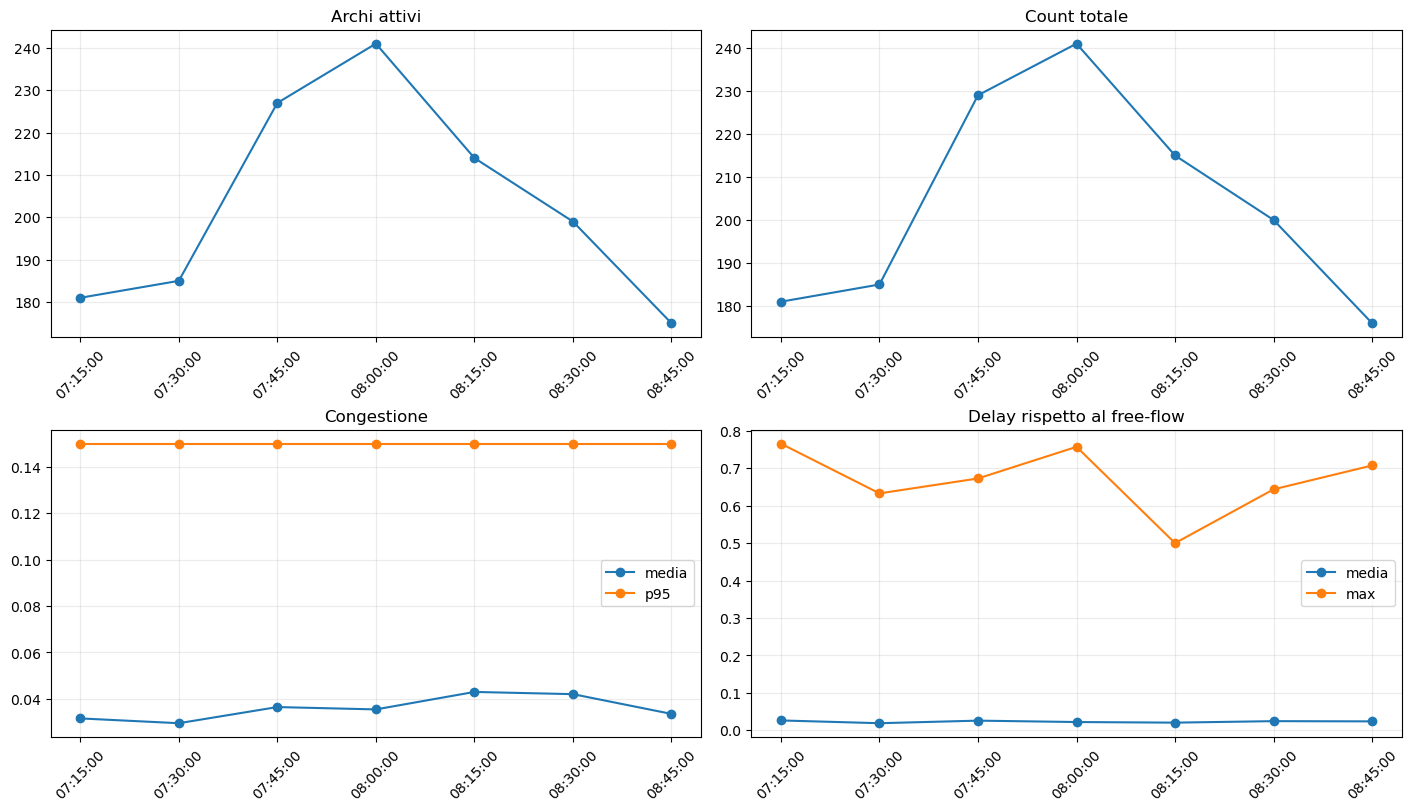

In [6]:
if not df.empty:
    agg = df.groupby(['seconds', 'time'], as_index=False).agg(
        edges=('edge_id', 'count'),
        active_edges=('edge_id', 'nunique'),
        total_count=('count', 'sum'),
        mean_count=('count', 'mean'),
        mean_congestion=('congestion', 'mean'),
        p95_congestion=('congestion', lambda x: x.quantile(0.95)),
        max_congestion=('congestion', 'max'),
        mean_travel_time_s=('travel_time_s', 'mean'),
        mean_delay_s=('delay_s', 'mean'),
        max_delay_s=('delay_s', 'max'),
    ).sort_values('seconds')
    display(agg)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
    axes = axes.ravel()
    axes[0].plot(agg['time'], agg['active_edges'], marker='o')
    axes[0].set_title('Archi attivi')
    axes[1].plot(agg['time'], agg['total_count'], marker='o')
    axes[1].set_title('Count totale')
    axes[2].plot(agg['time'], agg['mean_congestion'], marker='o', label='media')
    axes[2].plot(agg['time'], agg['p95_congestion'], marker='o', label='p95')
    axes[2].set_title('Congestione')
    axes[2].legend()
    axes[3].plot(agg['time'], agg['mean_delay_s'], marker='o', label='media')
    axes[3].plot(agg['time'], agg['max_delay_s'], marker='o', label='max')
    axes[3].set_title('Delay rispetto al free-flow')
    axes[3].legend()
    for ax in axes:
        ax.grid(True, alpha=0.25)
        ax.tick_params(axis='x', rotation=45)
    plt.show()

## Edge critici

In [7]:
if not df.empty:
    critical = df.sort_values(['congestion', 'count', 'delay_s'], ascending=False).head(20)
    display(critical[['time', 'edge_id', 'road_class', 'congestion', 'count', 'travel_time_s', 'free_flow_time_s', 'delay_s']])

    by_edge = df.groupby('edge_id', as_index=False).agg(
        observations=('edge_id', 'count'),
        max_congestion=('congestion', 'max'),
        mean_congestion=('congestion', 'mean'),
        max_count=('count', 'max'),
        total_count=('count', 'sum'),
        max_delay_s=('delay_s', 'max'),
    ).sort_values(['max_congestion', 'total_count'], ascending=False)
    display(by_edge.head(20))

,time,edge_id,road_class,congestion,count,travel_time_s,free_flow_time_s,delay_s
1161,08:30:00,131199,4,0.15,2,0.374215,0.325404,0.048811
135,07:15:00,187662,17,0.15,1,5.860958,5.096486,0.764472
818,08:00:00,310316,16,0.15,1,5.806748,5.049346,0.757402
54,07:15:00,40544,16,0.15,1,5.199448,4.521259,0.678189
405,07:45:00,24591,17,0.15,1,5.158889,4.485991,0.672898
1333,08:45:00,81283,16,0.15,1,4.937067,4.293102,0.643965
1209,08:30:00,247530,16,0.15,1,4.935761,4.291966,0.643795
503,07:45:00,133107,17,0.15,1,4.426486,3.849119,0.577367
390,07:45:00,13827,16,0.15,1,3.618944,3.146908,0.472036
745,08:00:00,153772,16,0.15,1,2.925316,2.543753,0.381563


,edge_id,observations,max_congestion,mean_congestion,max_count,total_count,max_delay_s
464,49296,2,0.15,0.15,1,2,0.022964
479,51806,2,0.15,0.15,1,2,0.052347
527,62284,2,0.15,0.15,1,2,0.046782
826,131199,1,0.15,0.15,2,2,0.048811
1067,210650,2,0.15,0.15,1,2,0.126806
1163,266806,2,0.15,0.15,1,2,0.009623
1,138,1,0.15,0.15,1,1,0.056363
3,356,1,0.15,0.15,1,1,0.052581
6,547,1,0.15,0.15,1,1,0.076002
7,552,1,0.15,0.15,1,1,0.096823


## Mappa rapida della rete

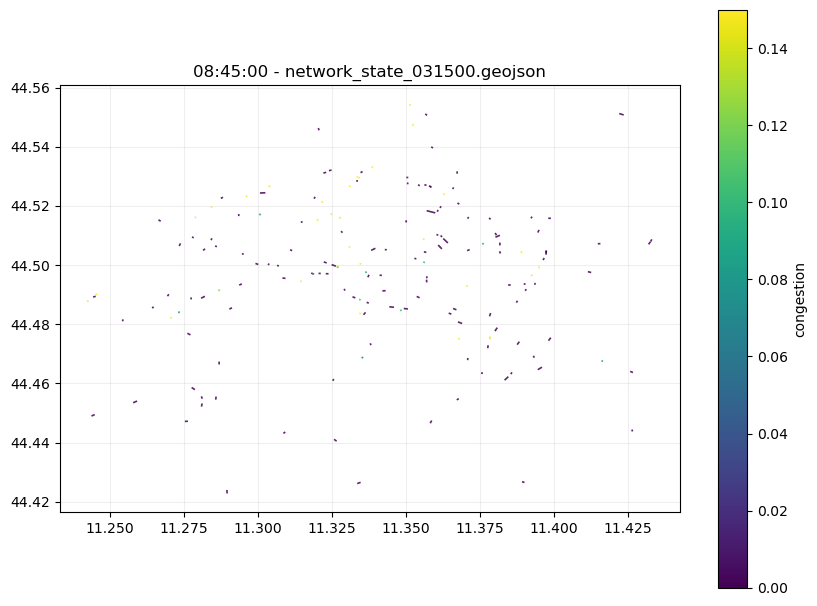

In [8]:
def iter_lines(geometry):
    if not geometry:
        return
    gtype = geometry.get('type')
    coords = geometry.get('coordinates')
    if gtype == 'LineString':
        yield coords
    elif gtype == 'MultiLineString':
        yield from coords


def plot_snapshot(snapshot_index=-1, color_by='congestion'):
    non_empty = [s for s in snapshots if s['feature_count'] > 0]
    if not non_empty:
        print('Nessuno snapshot non vuoto da plottare.')
        return
    s = non_empty[snapshot_index]
    values = []
    lines = []
    for feature in s['features']:
        props = feature.get('properties', {}) or {}
        value = props.get(color_by, np.nan)
        for line in iter_lines(feature.get('geometry')):
            if line:
                lines.append(line)
                values.append(value)

    values = pd.to_numeric(pd.Series(values), errors='coerce')
    cmap = plt.cm.viridis
    norm = plt.Normalize(values.min(), values.max()) if values.notna().any() else None

    fig, ax = plt.subplots(figsize=(10, 10))
    for line, value in zip(lines, values):
        xs = [point[0] for point in line]
        ys = [point[1] for point in line]
        color = cmap(norm(value)) if norm and pd.notna(value) else '0.5'
        ax.plot(xs, ys, color=color, linewidth=1.2, alpha=0.85)

    if norm:
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        fig.colorbar(sm, ax=ax, shrink=0.75, label=color_by)
    ax.set_title(f'{s["time"]} - {s["path"].name}')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.2)
    plt.show()


plot_snapshot(-1, color_by='congestion')

## Controlli rapidi di plausibilita

In [9]:
checks = []
checks.append(('almeno un file', len(FILES) > 0))
checks.append(('tutti i file caricati senza errori', len(errors) == 0))
checks.append(('tempi ordinati e univoci', summary['seconds'].is_monotonic_increasing and summary['seconds'].is_unique if not summary.empty else False))
checks.append(('almeno uno snapshot con feature', bool((summary['feature_count'] > 0).any()) if not summary.empty else False))

if not df.empty:
    checks.extend([
        ('edge_id sempre presente', df['edge_id'].notna().all()),
        ('congestion numerica e non negativa', df['congestion'].notna().all() and (df['congestion'] >= 0).all()),
        ('count numerico e non negativo', df['count'].notna().all() and (df['count'] >= 0).all()),
        ('travel_time_s >= 0', df['travel_time_s'].notna().all() and (df['travel_time_s'] >= 0).all()),
        ('free_flow_time_s >= 0', df['free_flow_time_s'].notna().all() and (df['free_flow_time_s'] >= 0).all()),
    ])

check_df = pd.DataFrame(checks, columns=['check', 'ok'])
display(check_df)

failed = check_df.loc[~check_df['ok']]
if failed.empty:
    print('OK: tutti i controlli rapidi sono passati.')
else:
    print('Attenzione: controlli falliti')
    display(failed)

,check,ok
0,almeno un file,True
1,tutti i file caricati senza errori,True
2,tempi ordinati e univoci,True
3,almeno uno snapshot con feature,True
4,edge_id sempre presente,True
5,congestion numerica e non negativa,True
6,count numerico e non negativo,True
7,travel_time_s >= 0,True
8,free_flow_time_s >= 0,True


OK: tutti i controlli rapidi sono passati.
